In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import classification_logistic
from importlib import reload
reload(classification_logistic)
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
import pickle 

In [2]:
#load data and did hot encoding 
heart_data=pd.read_csv('heart.csv')
y=heart_data["HeartDisease"]
X=heart_data.drop(columns=["HeartDisease",])

variable=['Sex','ChestPainType','RestingECG','ExerciseAngina','ST_Slope']
X=pd.get_dummies(data=X,prefix=variable,columns=variable)
print(X.dtypes)

Age                    int64
RestingBP              int64
Cholesterol            int64
FastingBS              int64
MaxHR                  int64
Oldpeak              float64
Sex_F                   bool
Sex_M                   bool
ChestPainType_ASY       bool
ChestPainType_ATA       bool
ChestPainType_NAP       bool
ChestPainType_TA        bool
RestingECG_LVH          bool
RestingECG_Normal       bool
RestingECG_ST           bool
ExerciseAngina_N        bool
ExerciseAngina_Y        bool
ST_Slope_Down           bool
ST_Slope_Flat           bool
ST_Slope_Up             bool
dtype: object


In [3]:
print(heart_data["FastingBS"].unique())

[0 1]


In [4]:
#here did split data into train,test and val data
x_train,x_,y_train,y_=train_test_split(X,y,test_size=0.4,random_state=55)


#here did split data into train,test and val data
x_test,x_val,y_test,y_val=train_test_split(x_,y_,test_size=0.5,random_state=55)

In [5]:
degrees=[1,2,3,4,5]

In [6]:
#find train accuracy ,model 
train_accuracy,val_accuracy,model,poly,scaler=classification_logistic.logistic_model(degrees,x_train,y_train,x_val,y_val)

/opt/anaconda3/envs/dl_env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/envs/dl_env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preproc

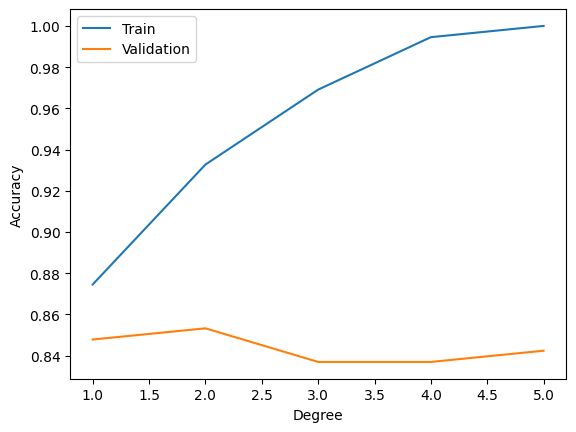

In [7]:
#plot graph
plt.plot(degrees,train_accuracy)
plt.plot(degrees,val_accuracy)
plt.xlabel('Degree')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])


In [8]:

#find optimla degree have best accuracy for validation data
optimal_degree=np.argmax(val_accuracy)+1

In [9]:
#list of all C
C_list = [0.001, 0.01, 0.1, 1,2,3]

In [10]:
#check best optimal value of C(intercept value)
acc_train_list,acc_val_list=classification_logistic.optimal_intercept(C_list,x_train,y_train,x_val,y_val,optimal_degree=1)


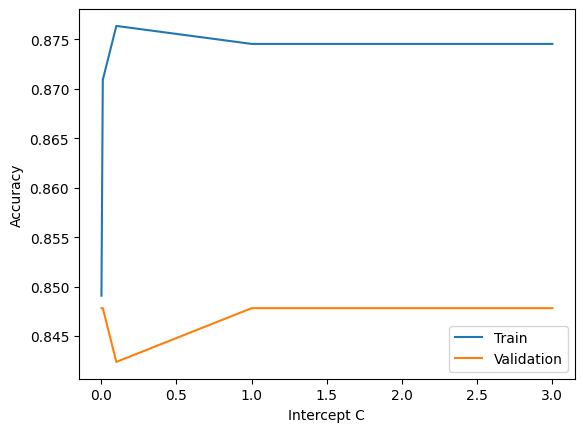

In [11]:
#plot graph for train and test accuracy
plt.plot(C_list,acc_train_list)
plt.plot(C_list,acc_val_list)
plt.xlabel('Intercept C')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])


In [12]:
#find optimum C index for model linear regression 
C_index=np.argmax(acc_val_list)
C_list[C_index]

0.001

In [13]:

#here mapped and scaled train and test data with best suited one
x_train_mapped=poly[optimal_degree-1].transform(x_train)
x_train_mapped_scaled=scaler[optimal_degree-1].transform(x_train_mapped)

x_test_mapped=poly[optimal_degree-1].transform(x_test)
x_test_mapped_scaled=scaler[optimal_degree-1].transform(x_test_mapped)




In [15]:
#train model logisitc regression at optimal parameter
model=LogisticRegression(C=C_list[C_index])
model.fit(x_train_mapped_scaled,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.001
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [16]:
#Save the trained model as a pickle file for future predictions
pickle.dump(model,open("heart_model.pkl","wb"))
pickle.dump(poly[optimal_degree-1],open("heart_poly.pkl","wb"))
pickle.dump(scaler[optimal_degree-1],open("heart_scaler.pkl","wb"))

In [60]:
#check accuracy for test data
y_test_predict=model.predict(x_test_mapped_scaled)